# 25 imágenes por segundo revelan el metabolismo de un cuerpo completo

**120 segundos hasta el corazón. 505 hasta el hígado. Y todo en un solo ratón vivo, en tiempo real.**

Un equipo de Caltech construyó un sistema de imagen que captura la fisiología del cuerpo completo a 25 cuadros por segundo, sin radiación ionizante y sin partir el cuerpo en cortes. Lo bautizaron 3D-PanoPACT y lo usaron para algo que antes solo se podía sospechar: ver cómo una molécula viaja, se acumula y se metaboliza órgano por órgano.

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-04-29-panopact-metabolismo-cuerpo-completo/notebook.ipynb) · [![Ver video](https://img.shields.io/badge/YouTube-Short-red)](https://youtube.com/shorts/ht9Ojc2vMes)

**Paper:** Wang et al. (2025). *Cross-regional real-time visualization of systemic physiology and dynamics with 3D panoramic photoacoustic computed tomography (3D-PanoPACT)*. **Nature Communications**. [DOI: 10.1038/s41467-025-65054-x](https://doi.org/10.1038/s41467-025-65054-x)


## ¿Qué resuelve PanoPACT?

La luz láser cercana al infrarrojo (NIR) atraviesa unos pocos milímetros de tejido antes de dispersarse — eso pone un techo a las técnicas puramente ópticas. La imagen fotoacústica esquiva ese techo: dispara un pulso láser, el tejido absorbe la luz, se calienta de forma microscópica y emite una onda acústica que sí puede viajar centímetros sin perderse. Tú "iluminas" con luz y "escuchas" con ultrasonido.

3D-PanoPACT (3D *Panoramic Photoacoustic Computed Tomography*) es un anillo hemiesférico de **1024 transductores** alrededor del animal que reconstruye un volumen 3D entero en cada pulso. La novedad: una sola adquisición de un pulso láser produce el volumen completo — no hay que escanear ni rotar nada. Eso desbloquea velocidad de cuadro real (hasta 25 Hz) sobre campos de visión grandes (60 a 120 mm).

Veamos cómo se traduce eso en tres decisiones técnicas concretas y en un experimento final donde una sonda fluorescente recorre el cuerpo de un ratón en menos de diez minutos.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
ORGANO_DESTACADO = 'Higado'   # Órgano de referencia para anomalía (75% del C_max)
COLOR_HIGADO = '#dc2626'      # Rojo CaM — hígado, anomalía
COLOR_OTROS = '#2563eb'       # Azul CaM — resto de órganos
COLOR_REFERENCIA = '#d97706'  # Ámbar — líneas de referencia
COLOR_CONTEXTO = '#059669'    # Emerald — segunda variable
FUENTE = 'Fuente: Wang et al. (2025), Nature Communications | DOI: 10.1038/s41467-025-65054-x'

# ══════════════════════════════════════════════════════════════
# Imports y estilo
# ══════════════════════════════════════════════════════════════
import os
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Cargar estilo CaM (local primero, fallback a GitHub raw)
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle',
            style_file)
plt.style.use(style_file)

os.makedirs('figuras', exist_ok=True)

# ══════════════════════════════════════════════════════════════
# Carga de datos — los 4 CSVs vienen del texto del paper (Open Access)
# ══════════════════════════════════════════════════════════════
pk = pd.read_csv('datos/a1094_pharmacokinetics.csv')
sens = pd.read_csv('datos/sensibilidad_transductor.csv')
modos = pd.read_csv('datos/modos_imagen.csv')
atten = pd.read_csv('datos/atenuacion_optica.csv')

print(f'Farmacocinética A1094:  {len(pk)} órganos')
print(f'Sensibilidad transductor: {len(sens)} radios evaluados')
print(f'Modos de imagen:         {len(modos)} configuraciones')
print(f'Atenuación óptica:       {len(atten)} mediciones empíricas')
print()
print('Rango de t_peak en A1094:', pk['t_peak_s'].min(), '→', pk['t_peak_s'].max(), 's')
print('Rango de C_max en A1094:', pk['c_max_pct'].min(), '→', pk['c_max_pct'].max(), '%')

Farmacocinética A1094:  6 órganos
Sensibilidad transductor: 3 radios evaluados
Modos de imagen:         5 configuraciones
Atenuación óptica:       4 mediciones empíricas

Rango de t_peak en A1094: 120 → 505 s
Rango de C_max en A1094: 14 → 75 %


## Aquí está.

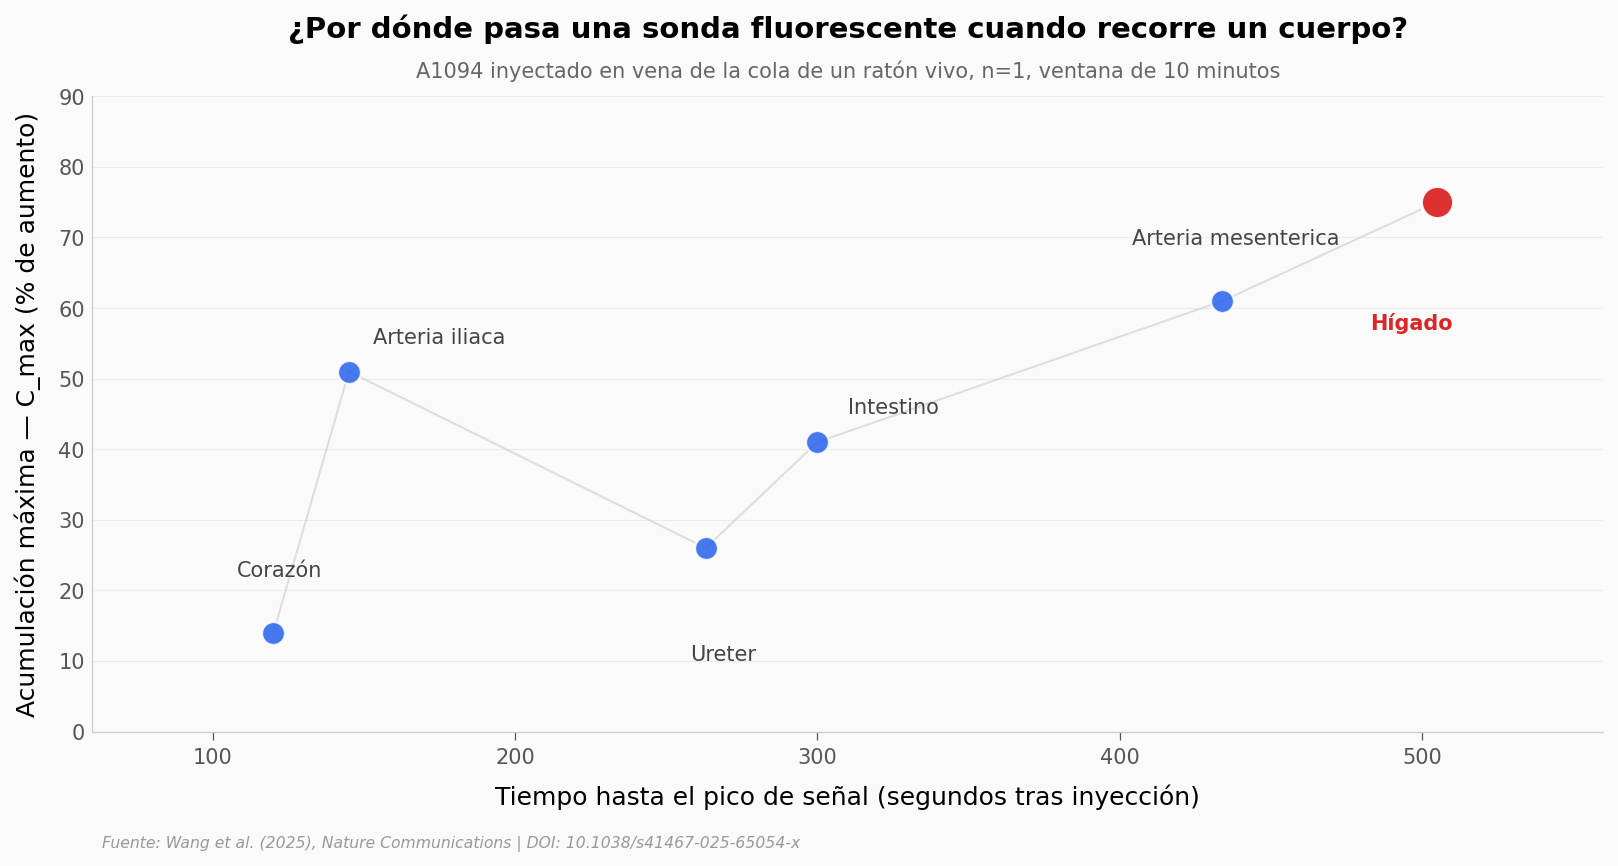

In [2]:
# Gráfica hero: cuándo llega y cuánto se acumula la sonda A1094 en cada órgano
fig, ax = plt.subplots(figsize=(13, 5.5))

# Separar hígado del resto para resaltar la anomalía
mask_higado = pk['organo'] == ORGANO_DESTACADO
otros = pk[~mask_higado].sort_values('t_peak_s')
higado = pk[mask_higado].iloc[0]

# Línea conectora: orden temporal (los órganos por los que pasa la sonda)
orden = pk.sort_values('t_peak_s')
ax.plot(orden['t_peak_s'], orden['c_max_pct'],
        color='#cccccc', linewidth=1.0, alpha=0.6, zorder=2)

# Resto de órganos
ax.scatter(otros['t_peak_s'], otros['c_max_pct'],
           color=COLOR_OTROS, s=120, alpha=0.85,
           edgecolors='white', linewidths=1.0, zorder=5)

# Hígado destacado
ax.scatter(higado['t_peak_s'], higado['c_max_pct'],
           color=COLOR_HIGADO, s=240, alpha=0.95,
           edgecolors='white', linewidths=1.5, zorder=6)

# Etiquetas inline para cada órgano
offsets = {
    'Corazon':            (-12, 8),
    'Arteria iliaca':     (8, 4),
    'Ureter':             (-5, -16),
    'Intestino':          (10, 4),
    'Arteria mesenterica':(-30, 8),
    'Higado':             (-22, -18),
}
for _, row in pk.iterrows():
    dx, dy = offsets.get(row['organo'], (8, 4))
    color = COLOR_HIGADO if row['organo'] == ORGANO_DESTACADO else '#444444'
    weight = 'bold' if row['organo'] == ORGANO_DESTACADO else 'normal'
    ax.annotate(row['organo'].replace('Higado', 'Hígado').replace('Corazon', 'Corazón'),
                xy=(row['t_peak_s'], row['c_max_pct']),
                xytext=(row['t_peak_s'] + dx, row['c_max_pct'] + dy),
                fontsize=10, color=color, fontweight=weight)

ax.set_xlabel('Tiempo hasta el pico de señal (segundos tras inyección)')
ax.set_ylabel('Acumulación máxima — C_max (% de aumento)')
ax.set_title('¿Por dónde pasa una sonda fluorescente cuando recorre un cuerpo?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'A1094 inyectado en vena de la cola de un ratón vivo, n=1, ventana de 10 minutos',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlim(60, 560)
ax.set_ylim(0, 90)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/01_farmacocinetica_a1094.png', dpi=200, bbox_inches='tight')
plt.show()

La línea gris une a los órganos en el orden en que la sonda los va alcanzando — es la "ruta" temporal. La forma de la curva delata el reparto fisiológico: el corazón ve la sonda primero (es la primera estación tras la vena de la cola) pero apenas la retiene; la arteria ilíaca registra el bolo arterial; intestino y arteria mesentérica hablan de circulación hepatoenterica; y al final, **el hígado**, no solo el último en el tiempo sino el más alto en concentración: ahí se queda.

La distancia entre 120 segundos y 505 segundos es lo que hace funcionar este método. Si el sistema fuera más lento, no podrías separar esos eventos — los verías como una sola "señal en el cuerpo". Con 25 imágenes por segundo, el orden temporal **es** el dato.

## El compromiso ingenieril que hace todo esto posible

Antes de la sonda y los ratones, hubo una decisión de diseño. Cada uno de los 1024 transductores que rodean al animal tiene un radio físico — y ese radio define un dilema. Si el transductor es muy pequeño, "ve" desde muchos ángulos (apertura amplia) pero capta muy poca señal acústica. Si es grande, capta señal fuerte pero solo desde una dirección estrecha.

El equipo simuló tres tamaños y midió el balance. Estos son los números que sustentan cada imagen del resto del notebook.

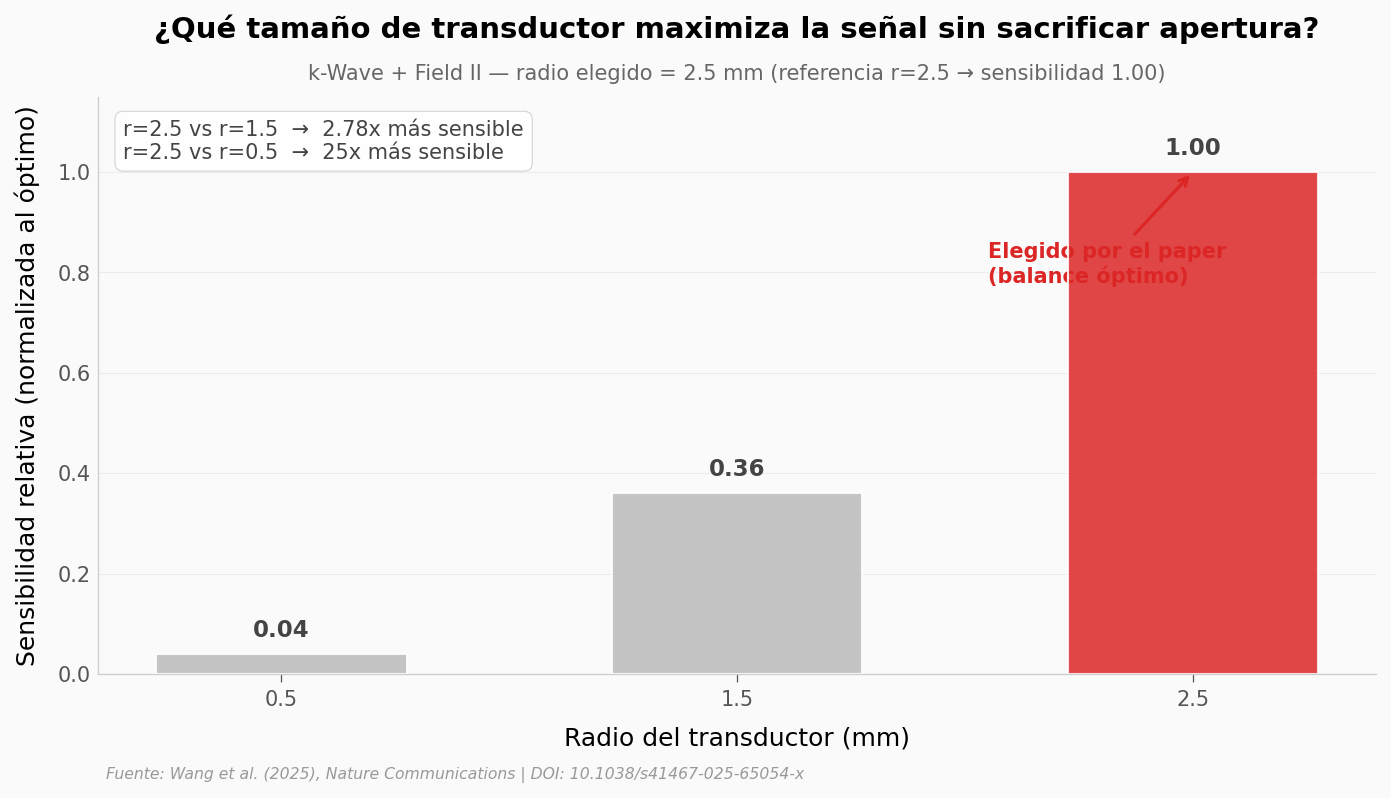

In [3]:
# Sensibilidad relativa del transductor por radio (simulaciones k-Wave + Field II)
fig, ax = plt.subplots(figsize=(11, 5))

colors_bars = ['#bbbbbb', '#bbbbbb', COLOR_HIGADO]  # destacar el elegido
bars = ax.bar(sens['radio_mm'].astype(str), sens['sensibilidad_relativa'],
              color=colors_bars, alpha=0.85, edgecolor='white', linewidth=1.0,
              width=0.55, zorder=5)

# Etiquetas encima de cada barra
for bar, val in zip(bars, sens['sensibilidad_relativa']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.025,
            f'{val:.2f}',
            ha='center', va='bottom', fontsize=11, fontweight='bold', color='#444444')

# Anotación del elegido
ax.annotate('Elegido por el paper\n(balance óptimo)',
            xy=(2, 1.0), xytext=(1.55, 0.78),
            fontsize=10, color=COLOR_HIGADO, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=COLOR_HIGADO, lw=1.5))

ax.set_xlabel('Radio del transductor (mm)')
ax.set_ylabel('Sensibilidad relativa (normalizada al óptimo)')
ax.set_title('¿Qué tamaño de transductor maximiza la señal sin sacrificar apertura?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'k-Wave + Field II — radio elegido = 2.5 mm (referencia r=2.5 → sensibilidad 1.00)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_ylim(0, 1.15)

# Inserta los ratios en texto
ax.text(0.02, 0.96, 'r=2.5 vs r=1.5  →  2.78x más sensible\nr=2.5 vs r=0.5  →  25x más sensible',
        transform=ax.transAxes, fontsize=10, color='#444444',
        verticalalignment='top',
        bbox=dict(facecolor='white', edgecolor='#cccccc', alpha=0.9, boxstyle='round,pad=0.4'))

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/02_sensibilidad_transductor.png', dpi=200, bbox_inches='tight')
plt.show()

## Cinco modos para cinco preguntas

Con los 1024 transductores fijados, el equipo programa el sistema en cinco modos distintos, cada uno con su propio compromiso entre **velocidad** (cuántas imágenes por segundo) y **campo de visión** (cuántos milímetros entran en cuadro). El rango cubre 125 veces — desde un solo pulso a 25 Hz hasta una pasada de cuerpo completo a 0.2 Hz.

Veamos el mapa de esos cinco modos.

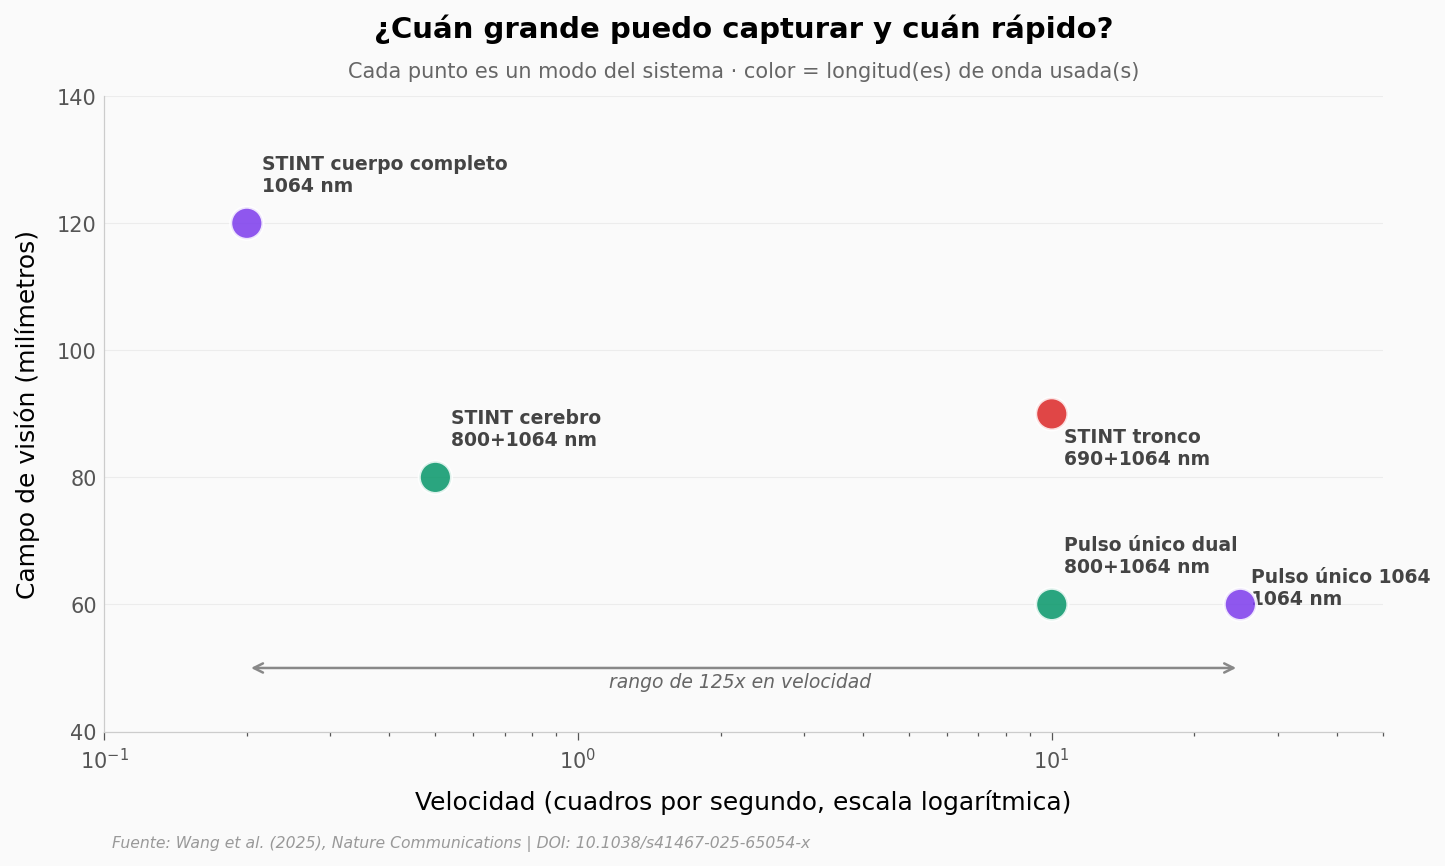

In [4]:
# Modos de imagen: trade-off velocidad vs campo de visión
fig, ax = plt.subplots(figsize=(11, 5.5))

# Mapeo de longitudes de onda a colores (más oscuro = más onda)
def color_for(w):
    if w == '1064':           return '#7c3aed'  # violeta
    if '690' in w:            return '#dc2626'  # rojo
    if '800' in w:            return '#059669'  # emerald
    return '#2563eb'

modos_sorted = modos.sort_values('frecuencia_hz')
colors_modos = [color_for(w) for w in modos_sorted['wavelengths']]

ax.scatter(modos_sorted['frecuencia_hz'], modos_sorted['fov_mm'],
           c=colors_modos, s=240, alpha=0.85,
           edgecolors='white', linewidths=1.5, zorder=5)

# Etiquetas a la derecha de cada punto
offsets_modos = {
    'Pulso unico 1064':       (1.3, 0),
    'Pulso unico dual':       (0.6, 5),
    'STINT cerebro':          (0.04, 5),
    'STINT tronco':           (0.6, -8),
    'STINT cuerpo completo':  (0.015, 5),
}
for _, row in modos_sorted.iterrows():
    dx, dy = offsets_modos.get(row['modo'], (0.5, 0))
    label = row['modo'].replace('unico', 'único')
    ax.annotate(f"{label}\n{row['wavelengths']} nm",
                xy=(row['frecuencia_hz'], row['fov_mm']),
                xytext=(row['frecuencia_hz'] + dx, row['fov_mm'] + dy),
                fontsize=9, color='#444444', fontweight='bold')

ax.set_xscale('log')
ax.set_xlabel('Velocidad (cuadros por segundo, escala logarítmica)')
ax.set_ylabel('Campo de visión (milímetros)')
ax.set_title('¿Cuán grande puedo capturar y cuán rápido?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Cada punto es un modo del sistema · color = longitud(es) de onda usada(s)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlim(0.1, 50)
ax.set_ylim(40, 140)

# Anotación del rango 125x
ax.annotate('', xy=(25, 50), xytext=(0.2, 50),
            arrowprops=dict(arrowstyle='<->', color='#888888', lw=1.2))
ax.text(2.2, 47, 'rango de 125x en velocidad',
        fontsize=9, color='#666666', ha='center', style='italic')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/03_modos_imagen.png', dpi=200, bbox_inches='tight')
plt.show()

## ¿Qué tan rara es la acumulación del hígado?

Vuelvo a la farmacocinética, pero ahora pongo el dato del hígado en contraste con el promedio del resto. La pregunta no es solo "el hígado captó más sonda que los demás"; es "**cuánto más**". Es ese contraste el que sostiene la idea de que el hígado es el órgano principal del metabolismo de A1094.

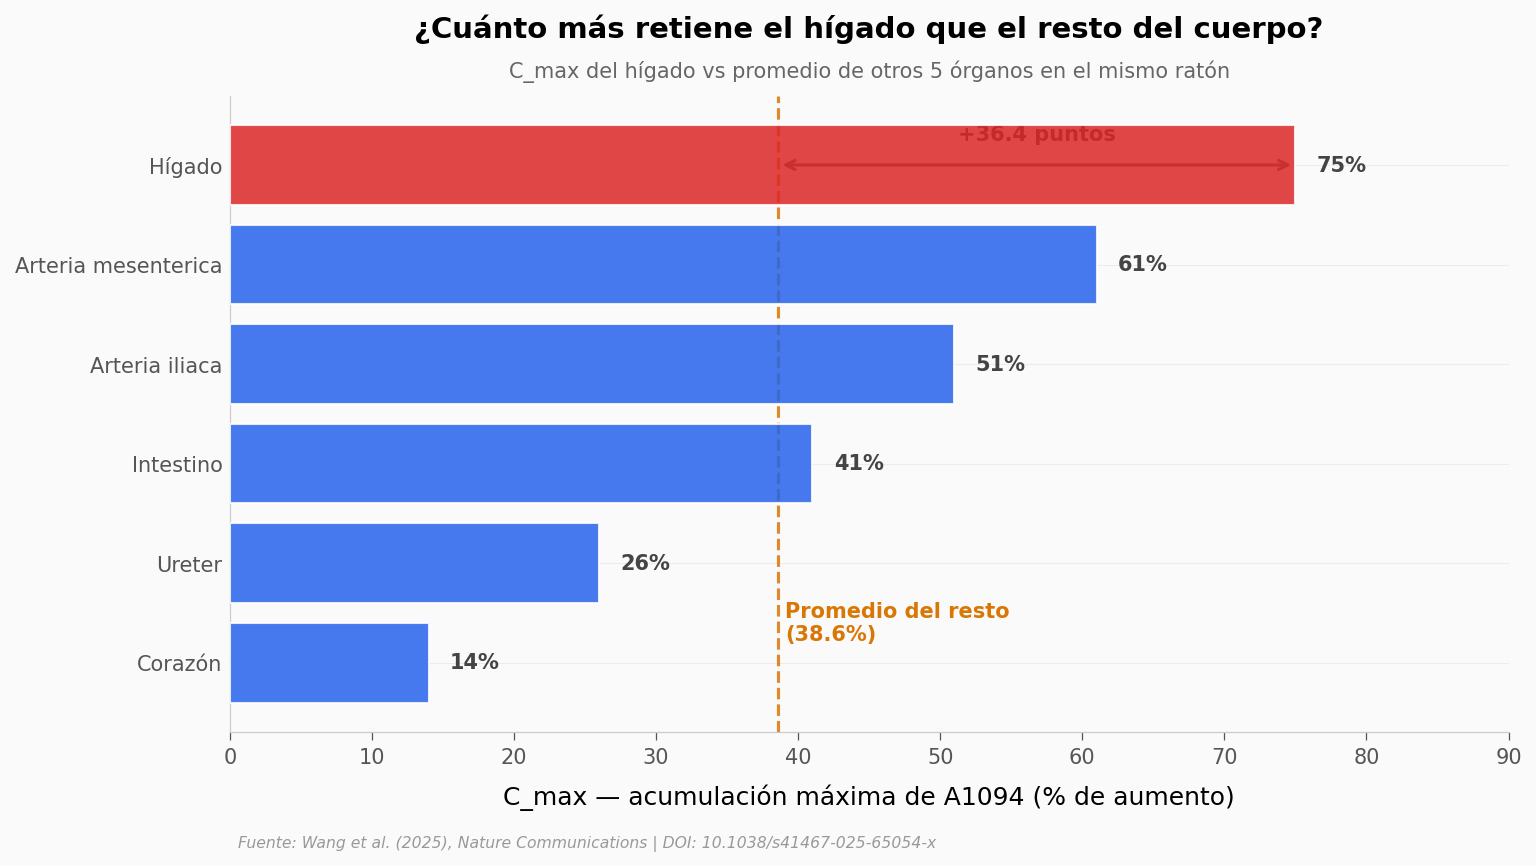

C_max del hígado:           75%
Promedio del resto (n=5):   38.6%
Razón hígado/resto:         1.94x


In [5]:
# Anomalía del hígado: C_max por órgano + media del resto
fig, ax = plt.subplots(figsize=(11, 5.5))

orden = pk.sort_values('c_max_pct', ascending=True)
mask_h = orden['organo'] == ORGANO_DESTACADO
colores = [COLOR_HIGADO if h else COLOR_OTROS for h in mask_h]

bars = ax.barh(orden['organo'].str.replace('Higado', 'Hígado').str.replace('Corazon', 'Corazón'),
               orden['c_max_pct'],
               color=colores, alpha=0.85, edgecolor='white', linewidth=1.0, zorder=5)

# Etiquetas a la derecha de cada barra
for bar, val in zip(bars, orden['c_max_pct']):
    ax.text(bar.get_width() + 1.5, bar.get_y() + bar.get_height()/2,
            f'{val}%',
            va='center', fontsize=10, color='#444444', fontweight='bold')

# Línea de referencia: promedio sin hígado
no_higado = pk[pk['organo'] != ORGANO_DESTACADO]['c_max_pct']
media_resto = no_higado.mean()
ax.axvline(x=media_resto, color=COLOR_REFERENCIA, linewidth=1.5, linestyle='--', alpha=0.85, zorder=3)
ax.text(media_resto + 0.5, 0.4,
        f'Promedio del resto\n({media_resto:.1f}%)',
        fontsize=10, color=COLOR_REFERENCIA, fontweight='bold', va='center')

# Flecha bidireccional: la diferencia
higado_val = pk[pk['organo'] == ORGANO_DESTACADO]['c_max_pct'].iloc[0]
ax.annotate('', xy=(higado_val, 5), xytext=(media_resto, 5),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text((higado_val + media_resto) / 2, 5.25,
        f'+{higado_val - media_resto:.1f} puntos',
        ha='center', fontsize=10, color='#444444', fontweight='bold')

ax.set_xlabel('C_max — acumulación máxima de A1094 (% de aumento)')
ax.set_title('¿Cuánto más retiene el hígado que el resto del cuerpo?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, f'C_max del hígado vs promedio de otros 5 órganos en el mismo ratón',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlim(0, 90)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/04_anomalia_higado.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'C_max del hígado:           {higado_val}%')
print(f'Promedio del resto (n=5):   {media_resto:.1f}%')
print(f'Razón hígado/resto:         {higado_val/media_resto:.2f}x')

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| El sistema captura imágenes a 25 Hz sobre el hígado completo | ✅ | Modo "Pulso único 1064" — frame rate de 25 Hz con FOV 60 mm. Métrica del paper, no calculada aquí. |
| El hígado es el órgano principal de retención de A1094 | ✅ | C_max=75%, +36.4 puntos sobre el promedio de los otros cinco órganos (38.6%). Razón ≈ 1.94x. |
| El paper distingue 6 órganos en una sola corrida | ✅ | El dataset reporta t_peak y C_max para 6 órganos. La vejiga aparece con C_max≈49% pero sin t_peak — no incluida en el ranking temporal. |
| El radio del transductor de 2.5 mm es el óptimo | ⚠️ | Soportado por simulación k-Wave + Field II del paper (no ejecutamos las simulaciones aquí, reproducimos los ratios reportados: 25x y 2.78x). |
| El rango de velocidad cubre 125x | ✅ | 25 Hz / 0.2 Hz = 125. Calculado directamente del dataset de modos. |

> **Limitaciones:** los datos provienen del texto del paper (Open Access), no del repositorio Figshare original (4.4 GB sin CSVs resumen). Esto significa que reproducimos las **métricas finales** publicadas, no los datos brutos crudos. La farmacocinética corresponde a **un solo ratón vivo** (n=1) — ventana experimental de 10 minutos; todo lo que se ve aquí es una demostración técnica, no un estudio poblacional. El paper se enmarca como prueba de concepto, no extiende los resultados a clínica humana.

## Ahora tú

Tres preguntas que puedes contestar cambiando una línea en el bloque de configuración o en la celda siguiente.

1. **¿Qué pasaría si hubieran elegido el transductor de r=1.5 mm?** El paper reporta que sería 2.78x menos sensible. Multiplica `sens.loc[2, 'sensibilidad_relativa']` por la frecuencia de imagen y observa si el sistema seguiría siendo viable a 25 Hz.

2. **¿Qué órgano es la "primera estación" después del corazón?** Ordena `pk` por `t_peak_s` y mira el segundo lugar — y nota que la primera arteria iliaca llega antes que el ureter, lo que ubica la sonda todavía en el sistema circulatorio.

3. **¿Cómo cambia la jerarquía si miras *cuándo* en vez de *cuánto*?** Cambia la variable de la barra de la última gráfica de `c_max_pct` a `t_peak_s` — el orden no es el mismo: el hígado deja de ser el más alto y pasa a ser el más tarde.

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta 3: el orden por C_max vs el orden por tiempo de pico
print('Orden por concentración máxima (mayor a menor):')
for _, row in pk.sort_values('c_max_pct', ascending=False).iterrows():
    nombre = row['organo'].replace('Higado','Hígado').replace('Corazon','Corazón')
    print(f"  {nombre:<22} C_max={row['c_max_pct']:>2}%   t_peak={row['t_peak_s']:>3}s")

print()
print('Orden por tiempo hasta el pico (más temprano a más tardío):')
for _, row in pk.sort_values('t_peak_s').iterrows():
    nombre = row['organo'].replace('Higado','Hígado').replace('Corazon','Corazón')
    print(f"  {nombre:<22} t_peak={row['t_peak_s']:>3}s   C_max={row['c_max_pct']:>2}%")

# Cambia la línea de abajo para explorar otra perspectiva:
# - 'c_max_pct' por 'organo' o 'sistema'
# - Ordena por nombre de órgano para ver el agrupamiento por sistema fisiológico
print()
print('Por sistema fisiológico:')
print(pk.groupby('sistema')[['t_peak_s','c_max_pct']].mean().round(1))

Orden por concentración máxima (mayor a menor):
  Hígado                 C_max=75%   t_peak=505s
  Arteria mesenterica    C_max=61%   t_peak=434s
  Arteria iliaca         C_max=51%   t_peak=145s
  Intestino              C_max=41%   t_peak=300s
  Ureter                 C_max=26%   t_peak=263s
  Corazón                C_max=14%   t_peak=120s

Orden por tiempo hasta el pico (más temprano a más tardío):
  Corazón                t_peak=120s   C_max=14%
  Arteria iliaca         t_peak=145s   C_max=51%
  Ureter                 t_peak=263s   C_max=26%
  Intestino              t_peak=300s   C_max=41%
  Arteria mesenterica    t_peak=434s   C_max=61%
  Hígado                 t_peak=505s   C_max=75%

Por sistema fisiológico:
              t_peak_s  c_max_pct
sistema                          
Circulatorio     132.5       32.5
Digestivo        367.0       51.0
Hepatico         505.0       75.0
Renal            263.0       26.0


## Fuentes

**Paper**: [Cross-regional real-time visualization of systemic physiology and dynamics with 3D panoramic photoacoustic computed tomography (3D-PanoPACT)](https://doi.org/10.1038/s41467-025-65054-x)  
*Nature Communications, 2025-11-18*

**Datos**: [3D-PanoPACT_Data_Code — repositorio Figshare oficial](https://figshare.com/articles/dataset/3D-PanoPACT_Data_Code/28443374)  
*Figshare, 2025-11-18 · ZIP de 4.4 GB no descargado; valores extraídos del texto del paper (Open Access)*

*15 afirmaciones verificadas contra estas fuentes*

---

**Repositorio:** [Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab) · Notebook reproducible bajo licencia MIT.
**Datos:** extraídos del texto del paper (Open Access — Nature Communications). Repositorio Figshare oficial referenciado, no descargado por tamaño (4.4 GB).
**Vídeo asociado:** [Ciencia a Mordiscos · Short](https://youtube.com/shorts/ht9Ojc2vMes)